# **Start up**

Load the data, get the features and labels, scale the features, then split the dataset, build a model and use different algorithms , and then calculate the accuracy of our model.

In [1]:
#Make necessary imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os, sys
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Classification task to detect Parkinsons

> Add blockquote



In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [2]:
df = pd.read_csv('/content/parkinsons.data')
df.head(n=10)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01_6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02_1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02_2,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02_3,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02_4,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [ ]:
df.shape

(195, 24)

In [ ]:
#find null Values in the data set

df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [ ]:
df.dtypes

,0
name,object
MDVP:Fo(Hz),float64
MDVP:Fhi(Hz),float64
MDVP:Flo(Hz),float64
MDVP:Jitter(%),float64
MDVP:Jitter(Abs),float64
MDVP:RAP,float64
MDVP:PPQ,float64
Jitter:DDP,float64
MDVP:Shimmer,float64


In [ ]:
for i in df.columns:
    print("*************************************************",i,"************************************************************")
    print()
    print(set(df[i].tolist()))
    print()

************************************************* name ************************************************************

{'phon_R01_S32_4', 'phon_R01_S01_4', 'phon_R01_S10_1', 'phon_R01_S35_5', 'phon_R01_S17_6', 'phon_R01_S27_2', 'phon_R01_S01_3', 'phon_R01_S04_3', 'phon_R01_S31_5', 'phon_R01_S32_2', 'phon_R01_S37_4', 'phon_R01_S44_5', 'phon_R01_S20_6', 'phon_R01_S31_4', 'phon_R01_S13_3', 'phon_R01_S44_2', 'phon_R01_S39_3', 'phon_R01_S32_5', 'phon_R01_S04_4', 'phon_R01_S42_6', 'phon_R01_S02_6', 'phon_R01_S32_6', 'phon_R01_S37_2', 'phon_R01_S13_2', 'phon_R01_S16_6', 'phon_R01_S18_6', 'phon_R01_S20_5', 'phon_R01_S06_2', 'phon_R01_S16_2', 'phon_R01_S25_5', 'phon_R01_S08_4', 'phon_R01_S20_2', 'phon_R01_S49_1', 'phon_R01_S08_2', 'phon_R01_S24_3', 'phon_R01_S13_1', 'phon_R01_S37_3', 'phon_R01_S44_3', 'phon_R01_S31_1', 'phon_R01_S19_5', 'phon_R01_S44_1', 'phon_R01_S16_4', 'phon_R01_S43_3', 'phon_R01_S05_2', 'phon_R01_S08_6', 'phon_R01_S16_5', 'phon_R01_S21_4', 'phon_R01_S43_5', 'phon_R01_S50_2', 

**Check Label Imbalance**


For the predictions - check disbalance for classes i want to predict

,status,values
0,1,147
1,0,48


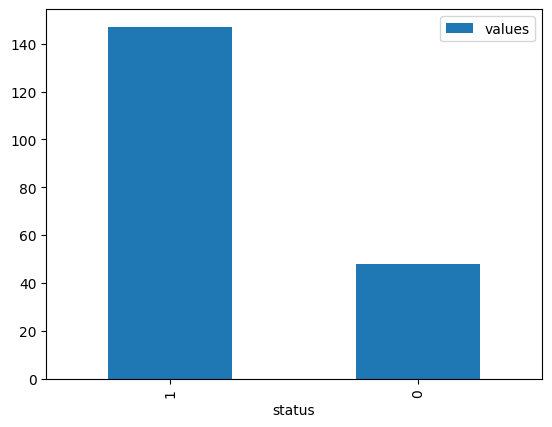

In [ ]:
import matplotlib.pyplot as plt

temp=df["status"].value_counts()
temp_df= pd.DataFrame({'status': temp.index, 'values': temp.values}) # creating df

temp_df.plot(kind='bar',x='status',y='values')
temp_df

"Check Label Imbalance" refers to the process of examining the distribution of classes in a dataset to determine if they are imbalanced. In classification problems, especially binary classification, label imbalance occurs when one class (label) is significantly more frequent than the other. This imbalance can affect the performance of machine learning models and lead to biased predictions.

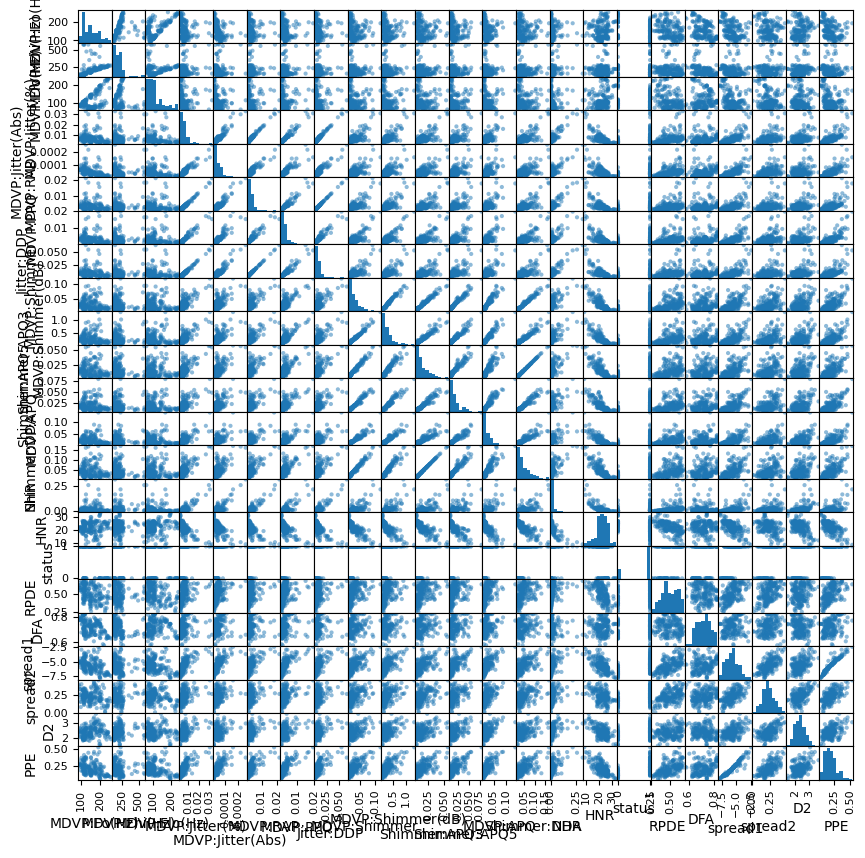

In [ ]:
pd.plotting.scatter_matrix(df.select_dtypes(include=['number']), figsize=(10, 10))
plt.show()

The distribution of a particular column:

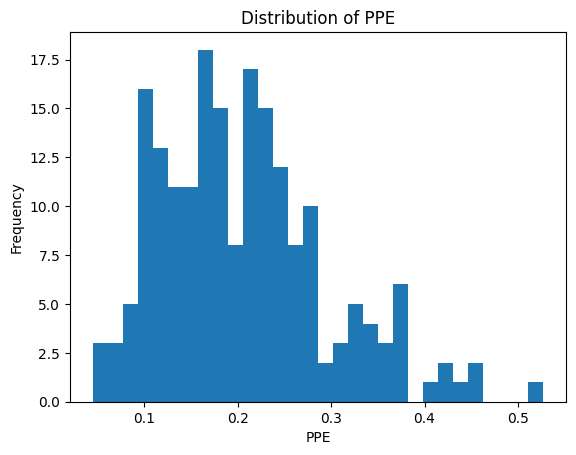

In [ ]:
plt.hist(df['PPE'], bins=30)
plt.xlabel('PPE')
plt.ylabel('Frequency')
plt.title('Distribution of PPE')
plt.show()

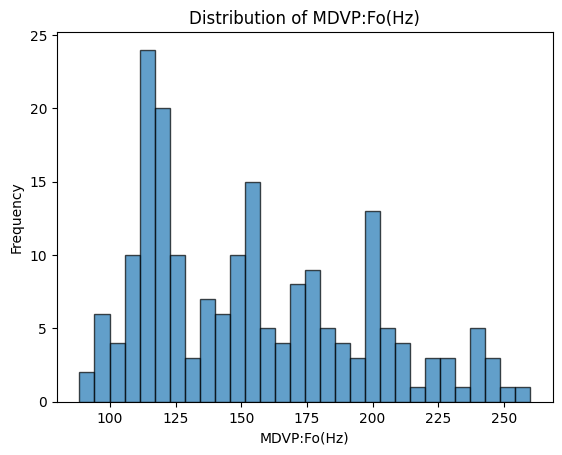

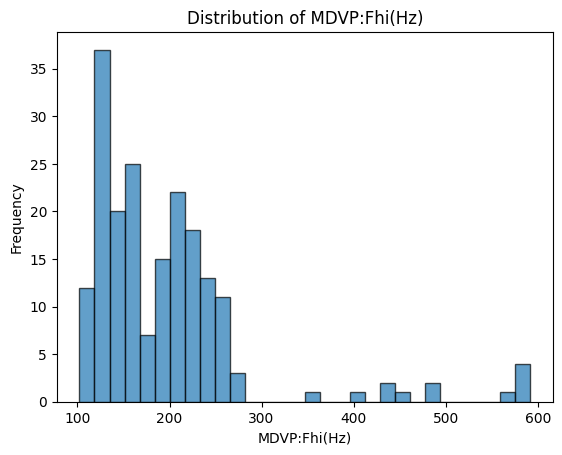

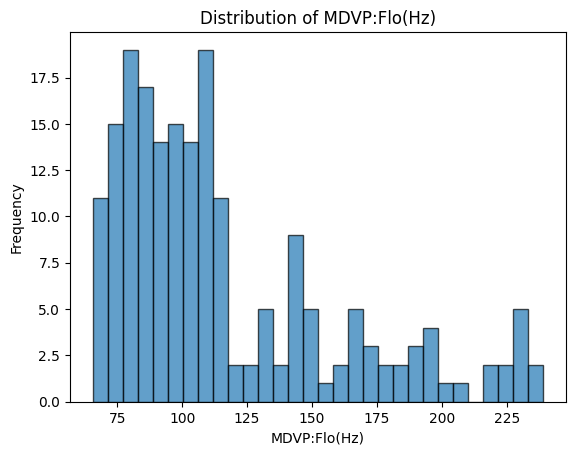

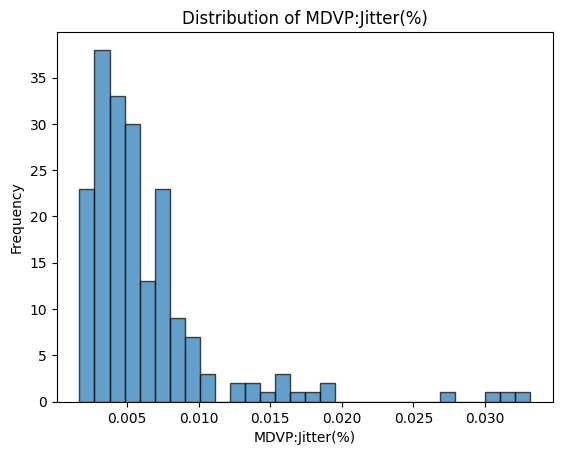

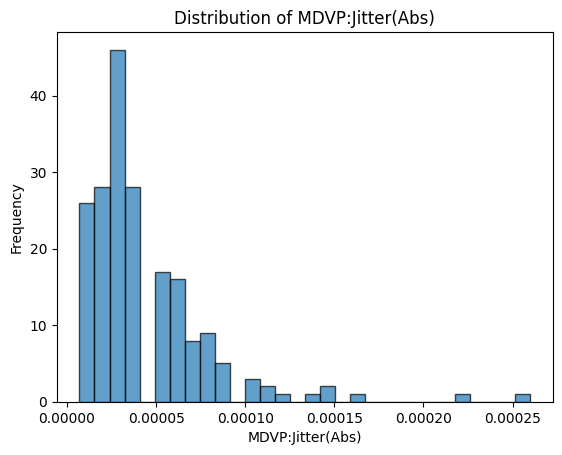

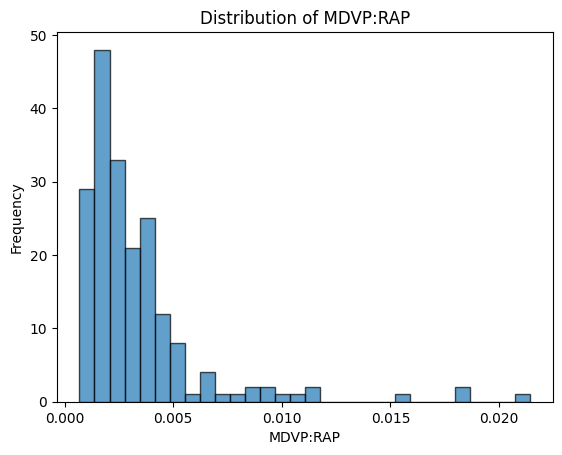

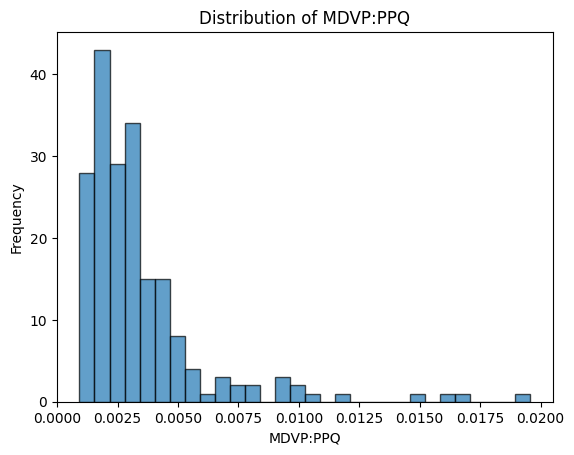

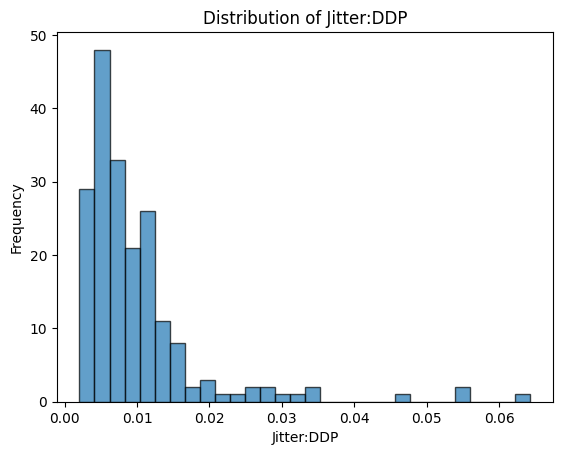

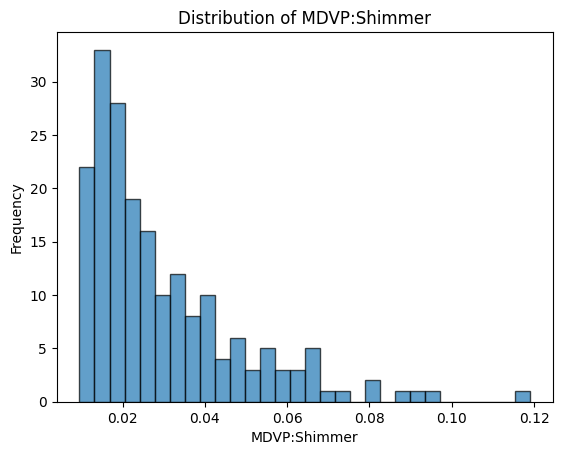

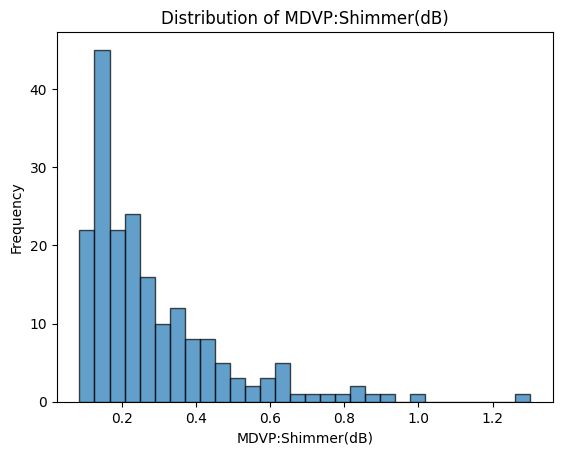

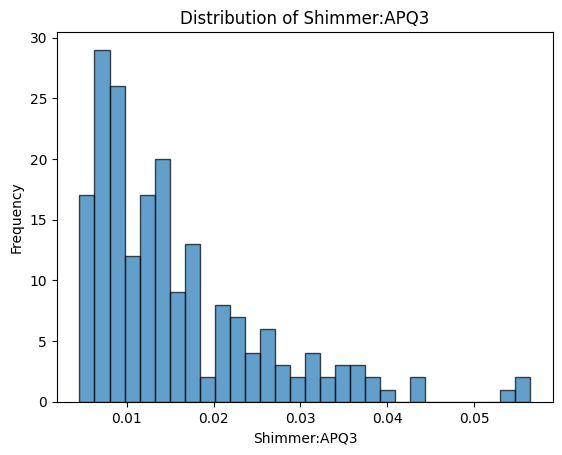

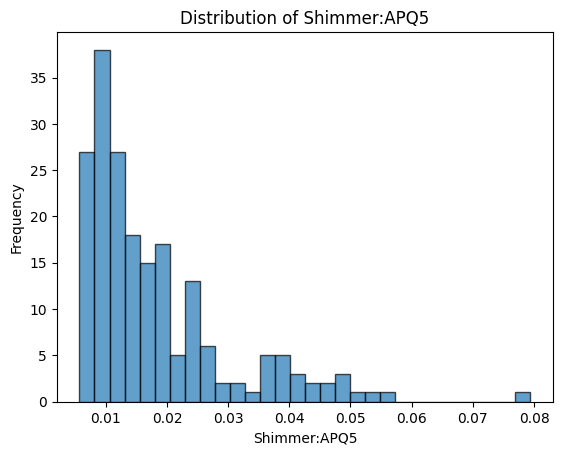

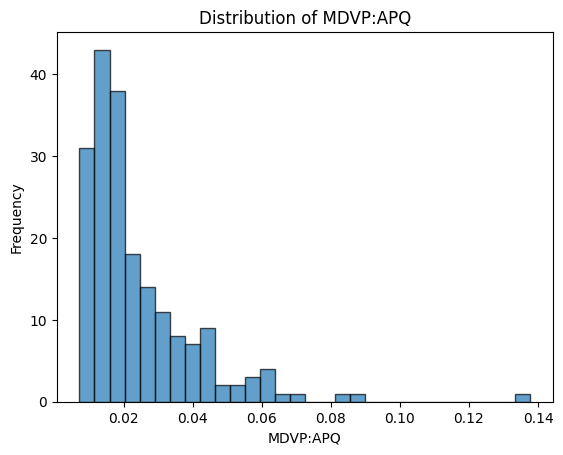

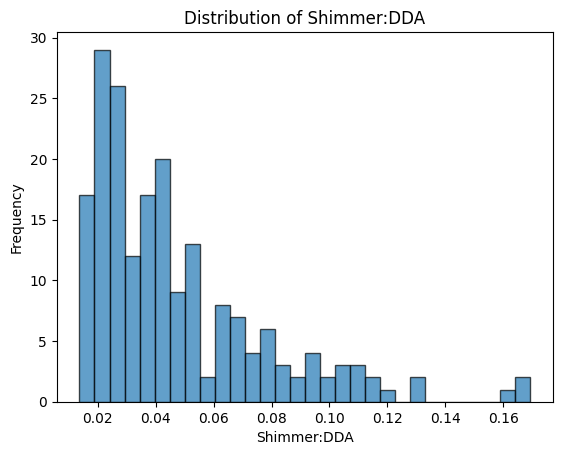

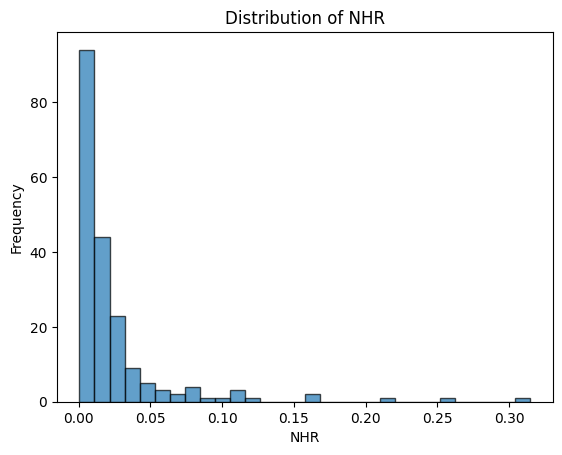

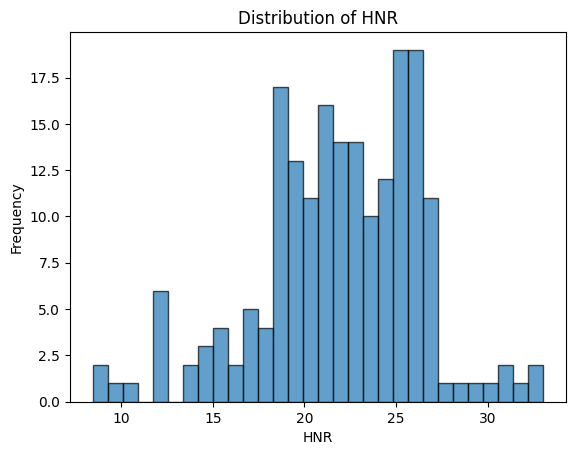

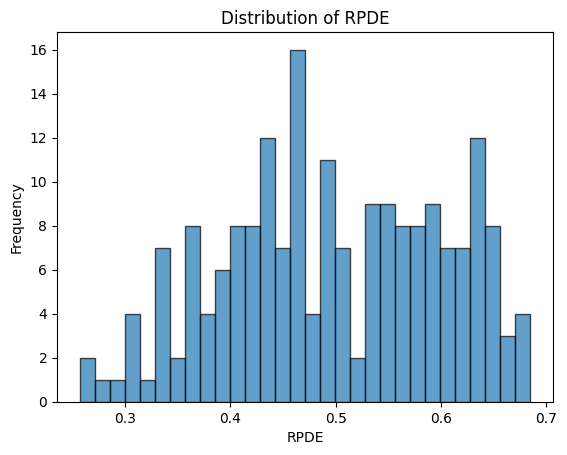

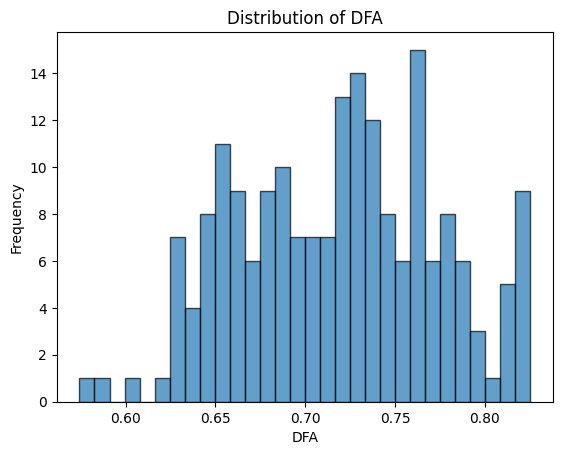

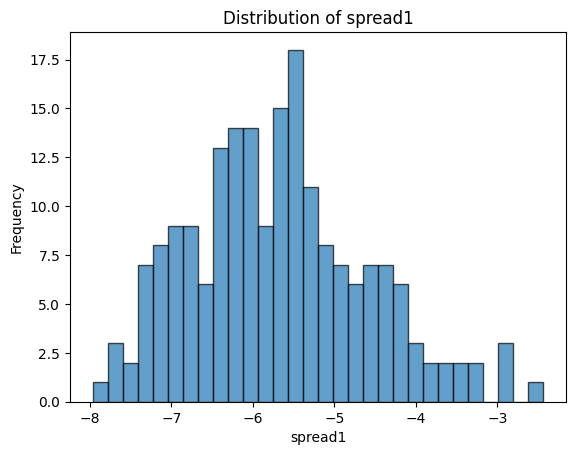

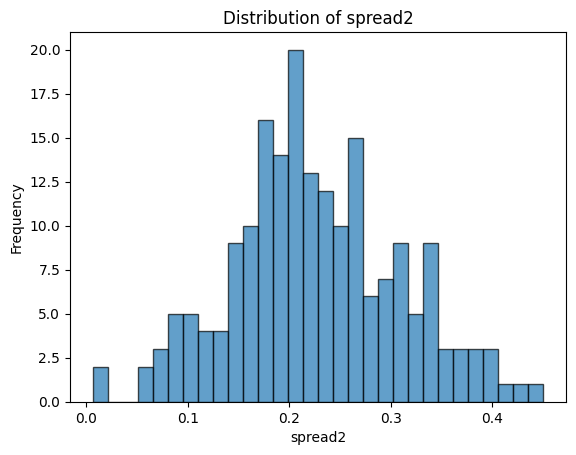

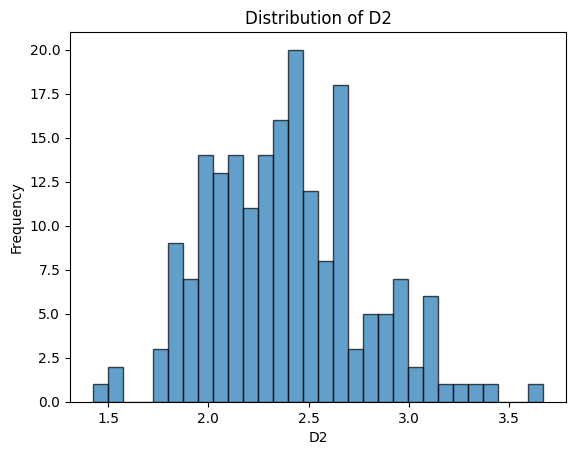

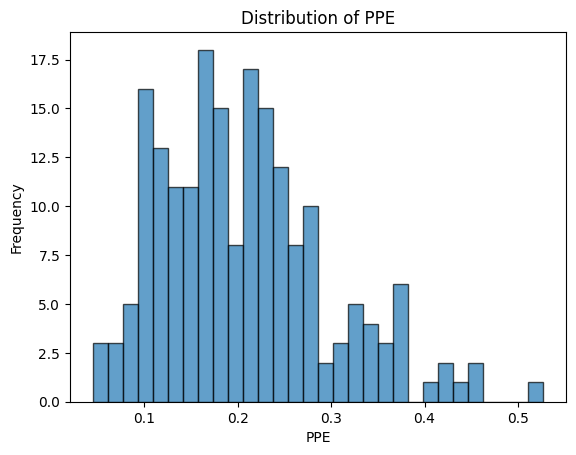

In [ ]:
# Define a function to plot the distribution of each column
def distplots(col):
    plt.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Loop over each column, excluding the first one (ID column)
for i in list(df.columns)[1:]:
  if i != 'status':
    distplots(i)


In any kind of ML-related modelling make sure that the algorithm we make/apply is applocable for the whole population.

Outliers are data points that are significantly different from the majority of the data. Techniques like detection, removal, transformation, and imputation are used to handle outliers. One of the best ways is using **Box Blocks/Plotting.**

While Imbalanced Data refers to a situation where the classes in the dataset are not represented equally. Techniques like resampling, using different evaluation metrics, and algorithmic adjustments are used to handle this issue.



1.   Detect the median
2.   Detect the Quartel
3.   Detect the Quartel three
4.   Detect the minimum
5.   Detect the maximum


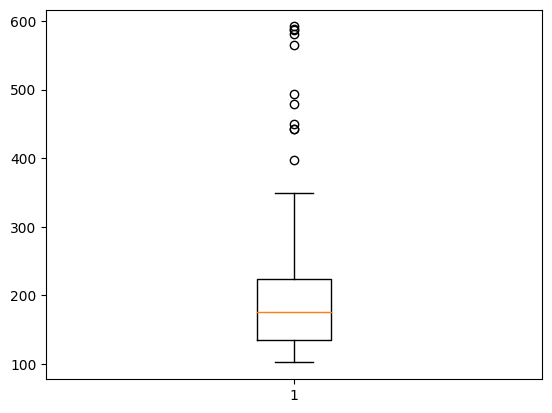

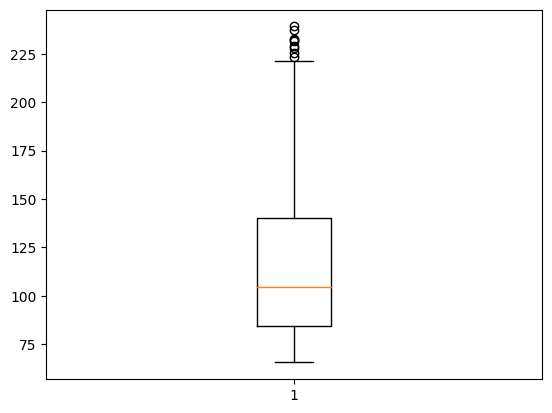

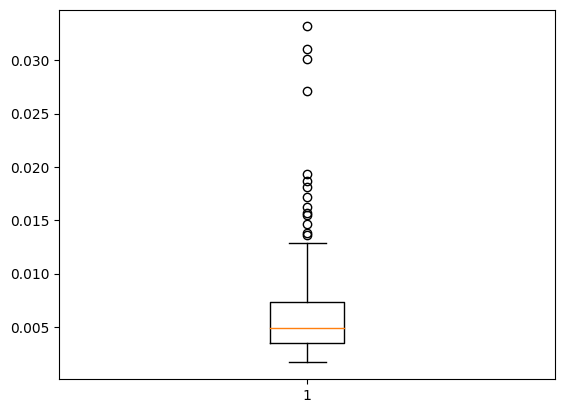

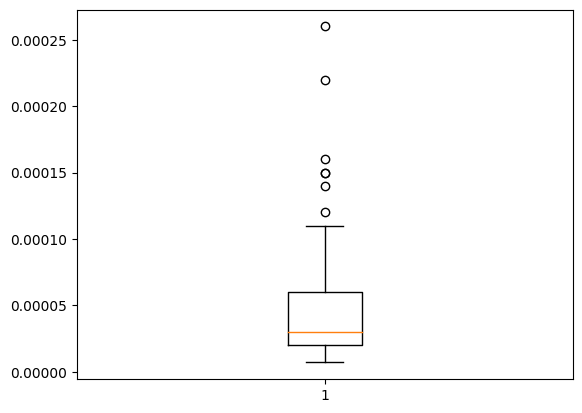

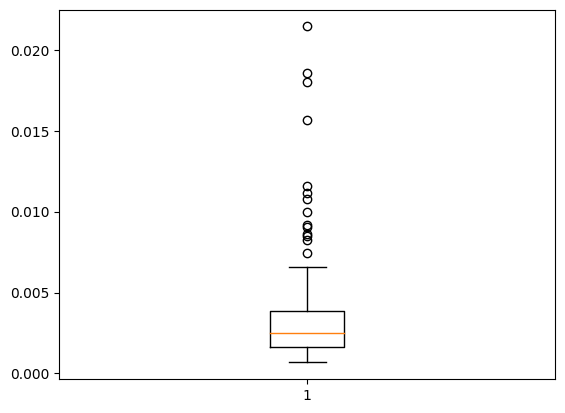

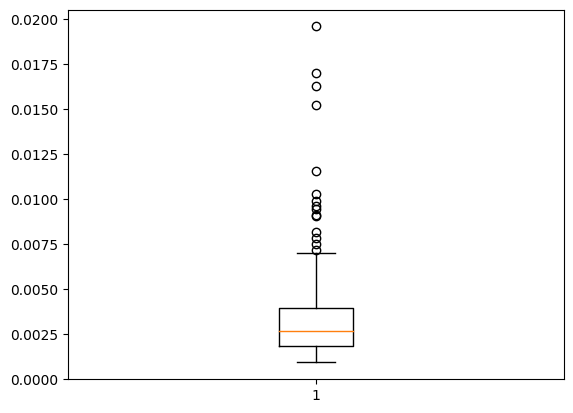

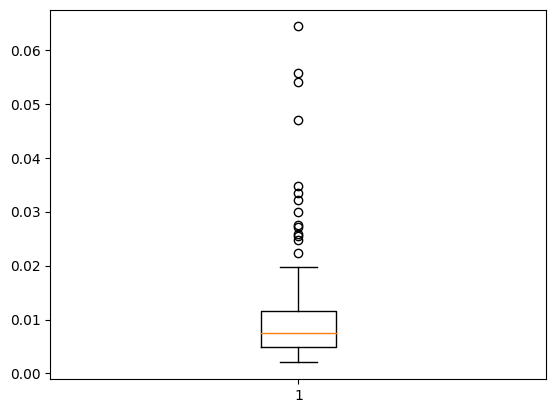

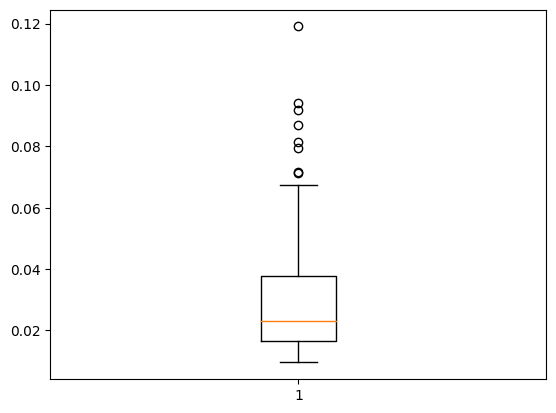

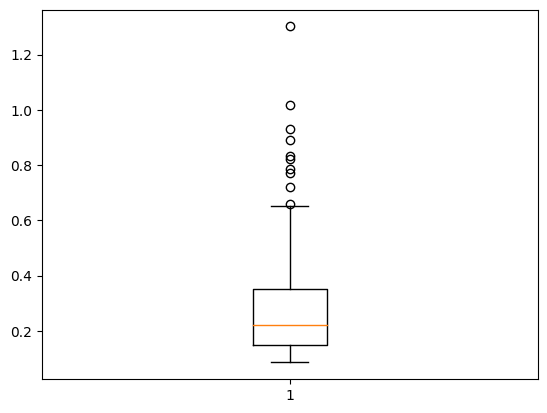

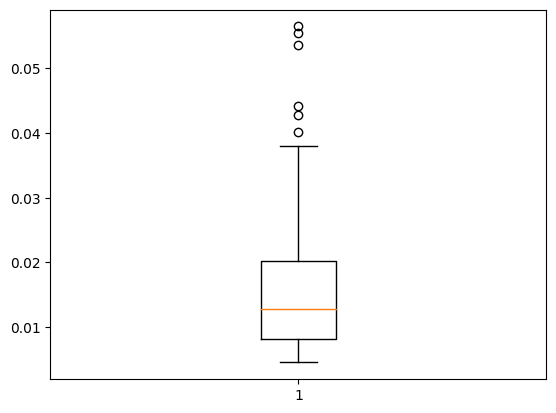

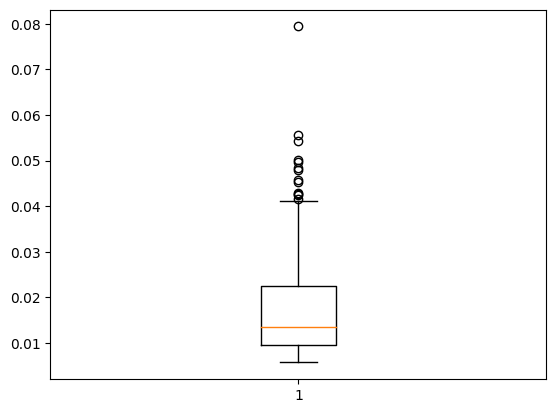

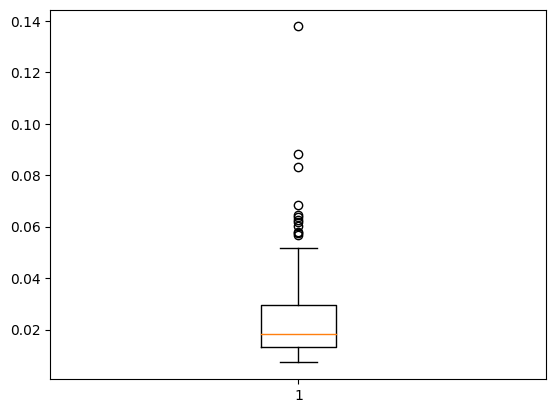

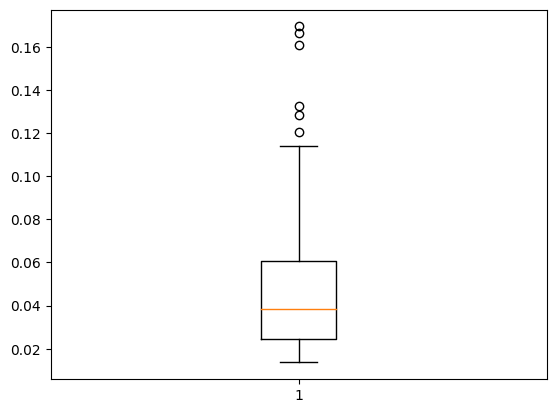

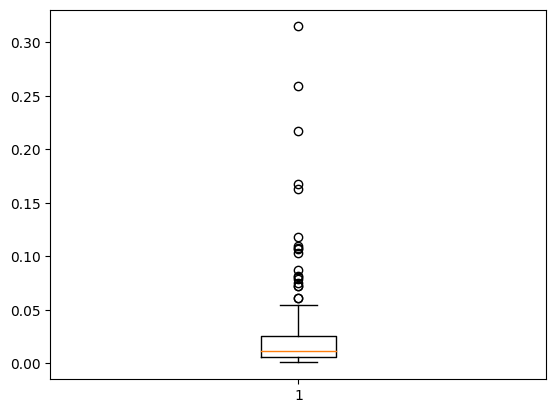

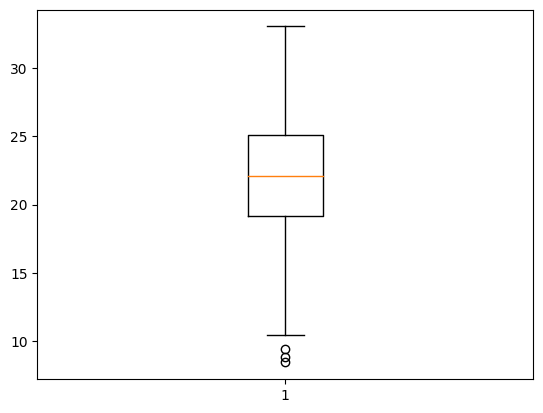

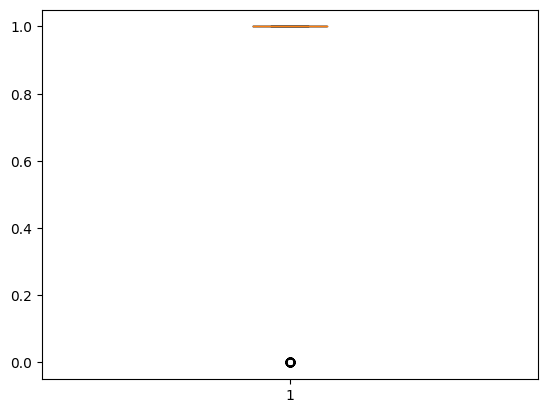

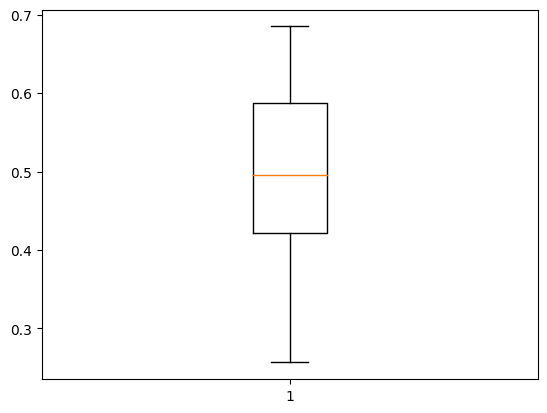

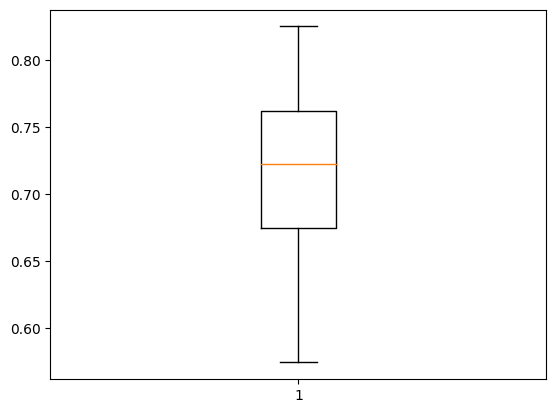

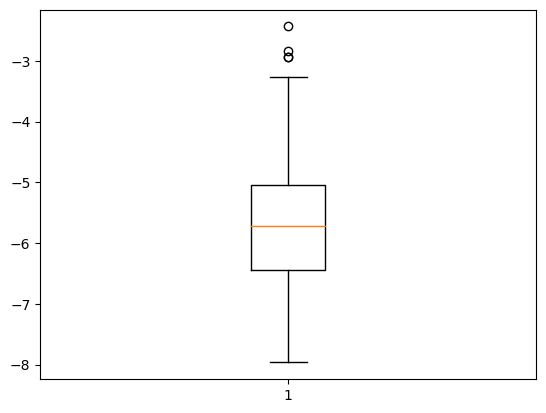

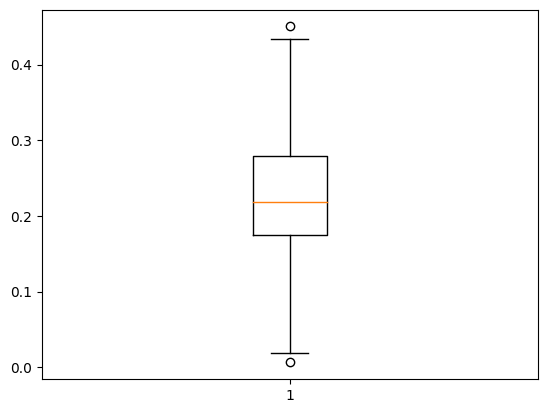

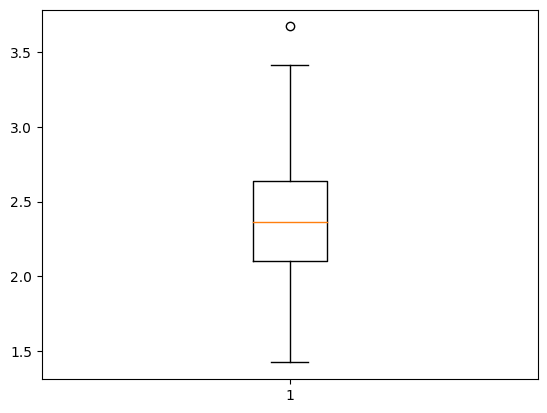

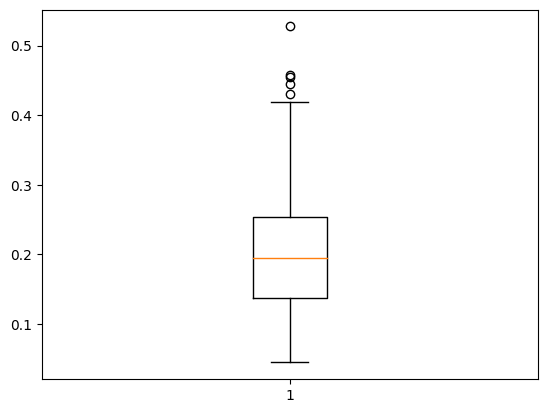

In [ ]:
# Find the distribution of data
def boxplots(col):
    # Ensures vertical orientation
    plt.boxplot(x=df[col])
    plt.show()

# exclude possible non-numerical values and slice the first id-column:
for i in list(df.select_dtypes(exclude=["object"]).columns)[1:]:
    boxplots(i)

# The box itself represents the interquartile range
### (IQR = Q3−Q1) ###
# which is the range where the middle 50% of the data lies.
# The bottom of the box is at the first quartile (Q1), or the 25th percentile,
# and the top of the box is at the third quartile (Q3), or the 75th percentile.
# The line inside the box represents the median (Q2), or the 50th percentile,
# which is the middle value of the dataset.

# The whiskers
### Lower Whisker: Q1 - 1,5 IQR ###
### Upper Whisker: Q3 + 1,5 IQR ###
# extend from each end of the box to cover a certain range of the data.
# They don’t necessarily go to the minimum and maximum values,
# but instead follow a specific rule to identify the range where most of the data lies.


# **CORRELATION**

**How** much does the shift in particular dataset affects another set of data?

heatmap

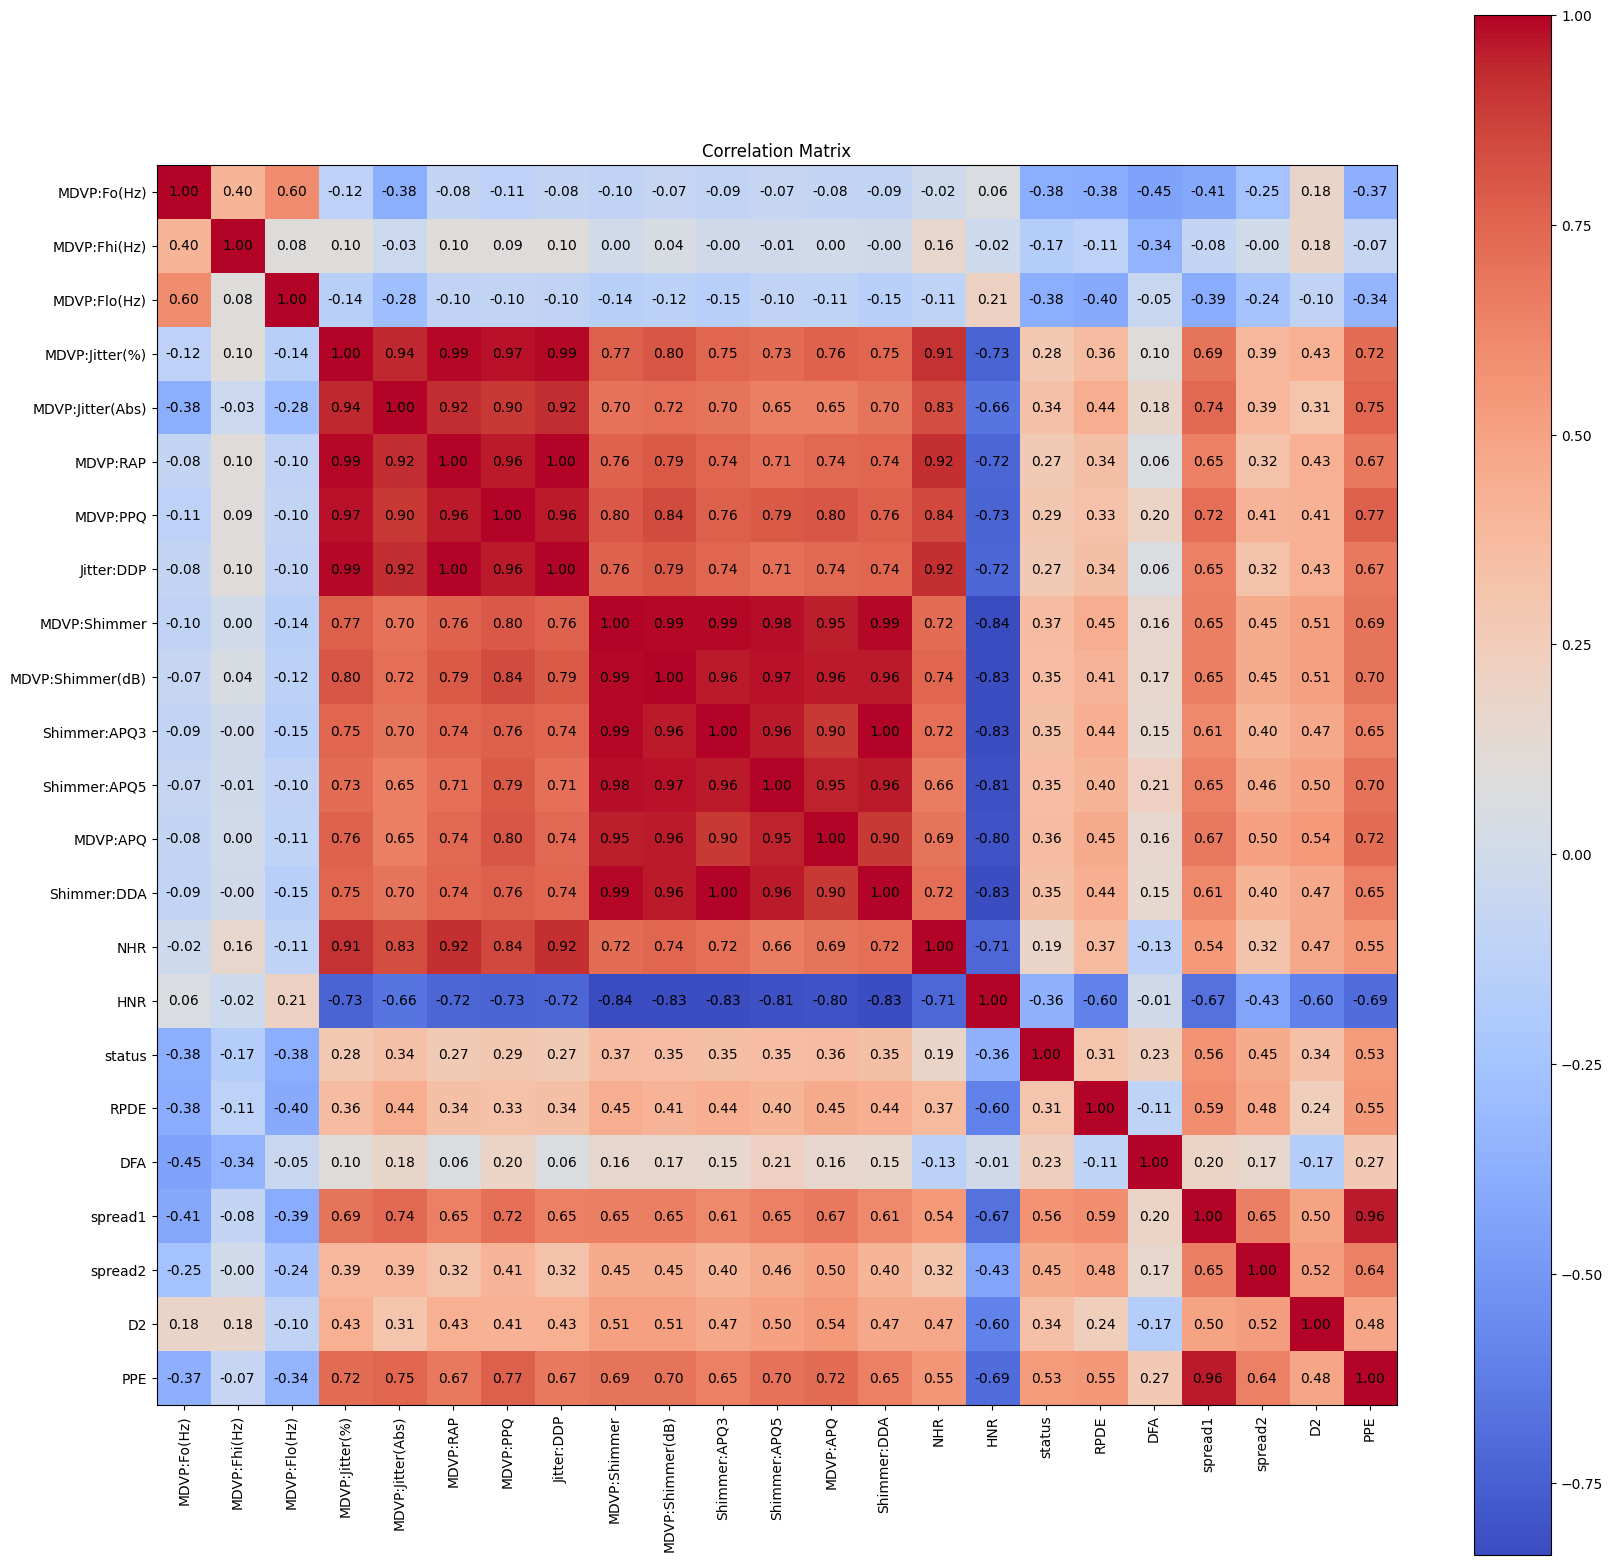

In [ ]:
# Select only numeric columns:
numeric_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr = numeric_df.corr()

# Create a heatmap using Matplotlib
plt.figure(figsize=(20,20))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest') #display the matrix as an image

# Add color bar
plt.colorbar()

# Add labels for each cell
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

# Set tick labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Title and display
plt.title("Correlation Matrix")
plt.show()

**Using This Information**

Feature Selection:

*   Strongly correlated variables may be redundant for a predictive model, so removing one of the variables from each pair with a high correlation to reduce multicollinearity might be considered.
*   If a variable is highly correlated with the target variable (status), it could be a good predictor for classification.

Data Understanding:
*  This matrix helps to understand relationships within the dataset. For example, in this dataset, many features related to jitter and shimmer (voice characteristics) have strong correlations with each other, which is expected in voice data analysis.

# **PREPARING DATA TO BE APPLIED ON ALGORITHMS**

In [ ]:
# Final changes to the data

# Seperate independent and dependent variables and drop the ID column
x=df.drop(["status","name"],axis=1) # remove from prediction
y=df["status"] # what we predict

In [ ]:
# Detect the label balance
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print(Counter(y))

Counter({1: 147, 0: 48})


In [ ]:
# Balance the labels
ros = RandomOverSampler()

X_ros, y_ros = ros.fit_resample(x, y)
print(Counter(y_ros))

Counter({1: 147, 0: 147})


 **SCALE DATA** - to avoid overfit with the models

---



In [ ]:
#Initialize a MinMaxScaler and scale the features to between -1 and 1 to normalize them.

#The MinMaxScaler transforms features by scaling them to a given range.
# Scaling is important in the algorithms such as
# support vector machines (SVM) and k-nearest neighbors (KNN) where distance
# between the data points is important.

scaler = MinMaxScaler((-1,1))

#The fit_transform() method fits to the data and then transforms it.
x= scaler.fit_transform(X_ros)
# No need to scale the labels.
y= y_ros

** Applying Feature Engineering and Principal Component Analysis (PCA)**

- is a technique used in data analysis and machine learning to reduce the number of features (dimensions) in a dataset while retaining as much of the original information as possible. It’s especially useful for simplifying large datasets, improving computational efficiency, and visualizing high-dimensional data

The most important use of PCA is to represent a multivariate data table as smaller set of variables (summary indices) in order to observe trends, jumps, clusters and outliers.

This overview may uncover the relationships between observations and variables, and among the variables.

In [ ]:
# Applying Feature Engineering and PCA
from sklearn.decomposition import PCA
# The .95 means that scikit-learn chooses the minimum number
# of principal components such that 95% of the variance is retained.
pca = PCA(.95)

X_PCA=pca.fit_transform(x)

print(x.shape)
print(X_PCA.shape)

# Thus we need 8 columns to keep 95% of the variance

(294, 22)
(294, 8)


So, 8 in response means that 8 columns represent 95% of the variance.

In [ ]:
#Now,split the dataset into training and testing sets keeping 20% of the data for testing.
#Split the dataset
x_train,x_test,y_train,y_test=train_test_split(X_PCA, y, test_size=0.2, random_state=7)
# 7 - sid -?

# **APPLYING ALGORITHM**

Done so far:
*  Preprocessed data
*   Fixed label imballance
*   Scaled the data
*   Did feature engineering
*   Reduced dimensions
*   Split the data

*Now* fit data into algorithms and check how well they are performing (checking accuracy and etc). Based on that select the best algorithm.

Importing evaluation metrics for evaluating classification models

*   confusion_matrix: This function returns a matrix that shows the number of true positives, true negatives, false positives, and false negatives. It helps you understand how well a classification model performed on each class.
*   accuracy_score: This function calculates the accuracy of the model: correctly_predicted_samples/total_samples.
*   f1_score: The F1 score is the harmonic mean of precision and recall, providing a balance between the two. It’s particularly useful when you have an imbalanced dataset, as it focuses on how well the model handles both positive and negative predictions.
*   precision_score: Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. It measures how precise or accurate the positive predictions are. Formula: True_Positives/(True_positives + False_pozitive).
*   recall_score: Recall (also known as sensitivity) is the ratio of correctly predicted positive observations to the actual positives. It measures the model's ability to detect positive samples. Formula: True_Positives/(True_Positives+False_Negatives)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

list_met=[]
list_accuracy=[]

# **Applying all the algorithms**

 Training and testing a models using the scikit-learn library:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Apply Logistic Regression using LogisticRegression algorithm
# creating an instance of the LogisticRegression model:
classifier=LogisticRegression(C=0.4,max_iter=1000,solver='liblinear')
# training the model:
lr=classifier.fit(x_train, y_train)
# making predictions on the test data
y_pred = classifier.predict(x_test)
#Accuracy
accuracy_LR= accuracy_score(y_test, y_pred)

# Apply Decision Tree
classifier2 = DecisionTreeClassifier(random_state=14)
dt=classifier2.fit(x_train, y_train)
y_pred2 = classifier2.predict(x_test)
accuracy_DT= accuracy_score(y_test, y_pred2)

# Apply Random Forest criteria=information gain
classifier3 = RandomForestClassifier(random_state=14)
rfi=classifier3.fit(x_train, y_train)
y_pred3 = classifier3.predict(x_test)
accuracy_RFI= accuracy_score(y_test, y_pred3)

# Apply Random Forest criteria=entropy
classifier4 = RandomForestClassifier(criterion='entropy')
rfe=classifier4.fit(x_train, y_train)
y_pred4 = classifier4.predict(x_test)
accuracy_RFE= accuracy_score(y_test, y_pred4)


list1=['Logistic Regression', 'Decison Tree', 'Random Forest(information gain)','Random Forest criteria=entropy']
list2=[accuracy_LR,accuracy_DT,accuracy_RFI,accuracy_RFE]
#train models:
list3=[classifier,classifier2,classifier3,classifier4]

                       Method Used  Accuracy
0              Logistic Regression  0.745763
1                     Decison Tree  0.932203
2  Random Forest(information gain)  0.983051
3   Random Forest criteria=entropy  0.983051
Axes(0.125,0.11;0.775x0.77)


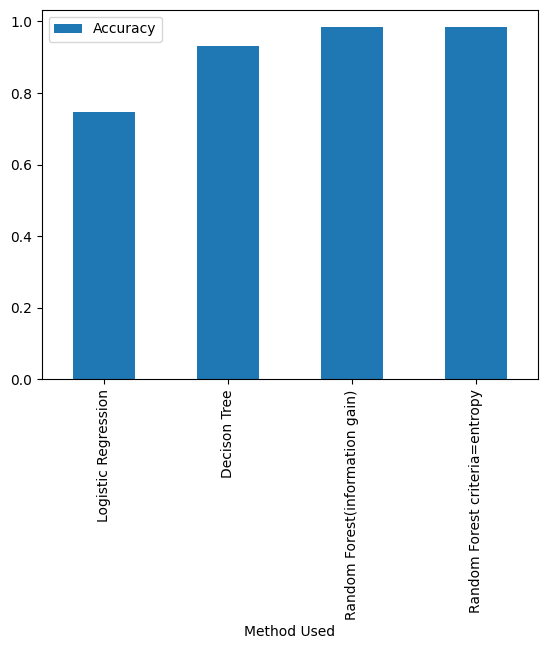

In [ ]:
df_Accuracy=pd.DataFrame({'Method Used':list1,'Accuracy': list2})
print(df_Accuracy)

chart=df_Accuracy.plot.bar(x='Method Used',y='Accuracy',rot=0)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
print(chart)

**Find** out true positives and false positive rates by creating the confusion metrics

In [ ]:
#Initialize an XGBClassifier and train the model.
#This classifies using eXtreme Gradient Boosting.
#It falls under the category of Ensemble Learning in ML,
#where we train and predict using many models to produce one superior output.

#Train the model
model_xg=XGBClassifier()
model_xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
#Generate y_pred (predicted values for x_test) and calculate the accuracy for the model.
y_pred=model_xg.predict(x_test)
#Calculate the accuracy
print(accuracy_score(y_test, y_pred)*100)

96.61016949152543


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, model_xg.predict(x_test))
print(cm)
#                   Predicted Negative (0)	Predicted Positive (1)
#Actual Negative (0)  23                     1
#Actual Positive (1)	1	                     34

[[23  1]
 [ 1 34]]


"""
Confusion matrices are used to visualize important predictive analytics like recall, specificity, accuracy, and precision.
Confusion matrices are useful because they give direct comparisons of values like True Positives, False Positives,
True Negatives and False Negatives.
"""

Precision: TP/(TP+FP)

Recall: TP/(TP+FN)

F1 Score: 0,5(Precision+Recall) - reaches its best value at 1 and worst score at 0.

The relative contribution of precision and recall to the F1 score are equal

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_test, model_xg.predict(x_test), average='binary')

0.9714285714285714

Classification report for XG-boost

In [ ]:
from sklearn.metrics import classification_report, roc_curve, auc, accuracy_score
print(classification_report(y_test, model_xg.predict(x_test)))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        24
           1       0.97      0.97      0.97        35

    accuracy                           0.97        59
   macro avg       0.96      0.96      0.96        59
weighted avg       0.97      0.97      0.97        59



# **Classification report**

In [ ]:
for i in list3:
    print("****************************************** ",i," **********************************************")
    print(classification_report(y_test, i.predict(x_test)))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, i.predict(x_test)))
    print()

******************************************  LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')  **********************************************
              precision    recall  f1-score   support

           0       0.68      0.71      0.69        24
           1       0.79      0.77      0.78        35

    accuracy                           0.75        59
   macro avg       0.74      0.74      0.74        59
weighted avg       0.75      0.75      0.75        59

Confusion Matrix:
[[17  7]
 [ 8 27]]

******************************************  DecisionTreeClassifier(random_state=14)  **********************************************
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        24
           1       0.97      0.91      0.94        35

    accuracy                           0.93        59
   macro avg       0.93      0.94      0.93        59
weighted avg       0.94      0.93      0.93        59

Confusion Matrix:
[[23 

In [ ]:
# Visualizing performance with ROC
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test):
    # calculate the fpr and tpr for all thresholds of the classification
    probabilities = model.predict_proba(np.array(X_test))
    predictions = probabilities
    fpr, tpr, threshold = roc_curve(y_test, predictions[:,1])
    roc_auc = auc(fpr, tpr)

    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label='AUC = %0.2f' % roc_auc)
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

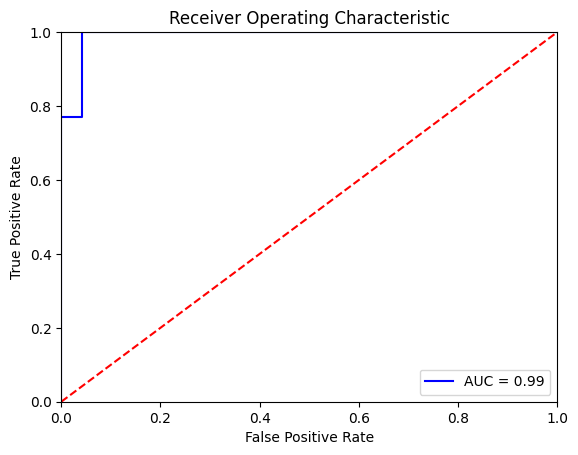

In [ ]:
plot_roc(model_xg, x_test, y_test)

Then we will start getting curves which are above the line. The closer to the line, the worse model is, the farther those away from the line, the better model is.


------------------ROC FOR  Logistic Regression  + PCA ---------------------------


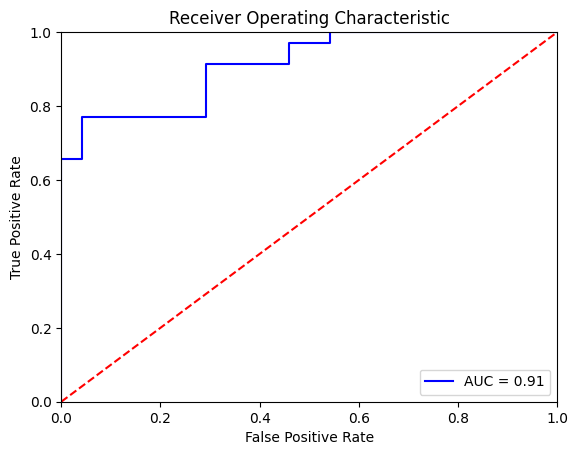



------------------ROC FOR  Decison Tree  + PCA ---------------------------


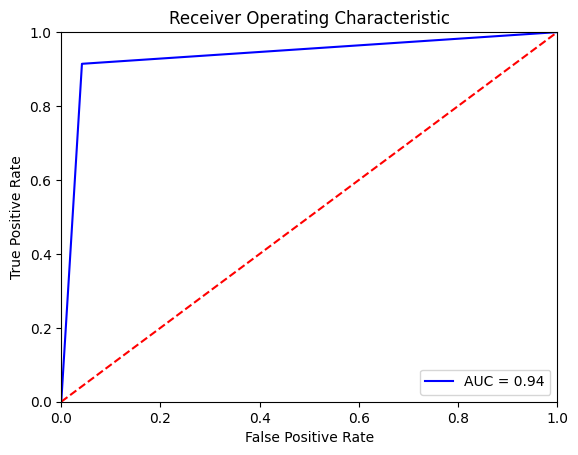



------------------ROC FOR  Random Forest(information gain)  + PCA ---------------------------


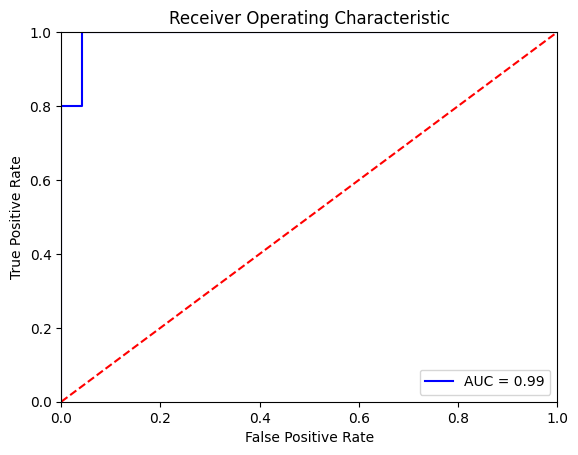

In [ ]:
for i in range(0,len(list3)):
    try:
        print()
        print("------------------ROC FOR ",list1[i]," + PCA ---------------------------")
        plot_roc(list3[i], x_test, np.array(y_test))
        print()
    except:
        print("roc not valid")